#Homework 04

Your turn: Home work:
Problem 7.5. from: Peter K. Dunn · Gordon K. Smyth Generalized Linear Models With Examples in R https://link.springer.com/content/pdf/10.1007/978-1-4419-0118-7.pdf
Nambe Mills, Santa Fe, New Mexico, is a tableware manufacturer. After casting, items produced by Nambe Mills are shaped, ground, buffed, and polished. In 1989, as an aid to rationalizing production of its 100 products, the company recorded the total grinding and polishing times and the diameter of each item (data set: nambeware). In this problem, only consider the item price y and item diameter x. In Problem 6.11, a glm was fitted to these data.
1. Use a Wald test to determine if diameter is significant.
2. Use a score test to determine if diameter is significant.
3. Use a likelihood ratio test to determine if diameter is significant.
4. Compare the results from the Wald, score and likelihood ratio tests. Comment.
5. Is the saddlepoint approximation expected to be accurate? Explain.
6. Is the Central Limit Theorem expected to be accurate? Explain.
7. Find the 95% Wald confidence intervals for the regression coefficients.
8. Plot the price against diameter, and show the relationship described by the fitted model. Also plot the lines indicating the lower and upper 95% confidence intervals for these fitted value


In [2]:


import numpy as np
import pandas as pd

import scipy
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.api import abline_plot

import sklearn

import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme()

import os
import sys

# Detect environment and load helpers accordingly
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q wget
    import wget
    url = "https://github.com/francji1/01ZLMA/raw/main/code/helpers.py"
    wget.download(url, '../content/helpers.py')
else:
    helpers_dir = os.path.dirname(os.path.abspath('__file__'))
    if helpers_dir not in sys.path:
        sys.path.insert(0, helpers_dir)

from helpers import Anova



  Preparing metadata (setup.py) ... done


In [3]:
# Load the R magic extension
%load_ext rpy2.ipython


In [4]:

%%R
install.packages("GLMsData")
library(GLMsData)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/GLMsData_1.4.tar.gz'
Content type 'application/x-gzip' length 161802 bytes (158 KB)
downloaded 158 KB


The downloaded source packages are in
	‘/tmp/Rtmpfo7uSL/downloaded_packages’


In [5]:


%%R -o nambeware
data(nambeware)
nambeware

       Type Diam   Time Price
1  CassDish 10.7  47.65 144.0
2  CassDish 14.0  63.13 215.0
3  CassDish  9.0  58.76 105.0
4      Bowl  8.0  34.88  69.0
5      Dish 10.0  55.53 134.0
6  CassDish 10.5  43.14 129.0
7      Tray 16.0  54.86 155.0
8      Tray 15.0  44.14  99.0
9      Dish  6.5  17.46  38.5
10     Dish  5.0  21.04  36.5
11     Tray 25.0 109.38 260.0
12     Bowl 10.4  17.67  54.0
13     Bowl  7.4  16.41  39.0
14     Bowl  5.4  12.02  29.5
15 CassDish 15.4  49.48 109.0
16 CassDish 12.4  48.74  89.5
17     Bowl  6.0  23.21  42.0
18     Bowl  9.0  28.64  65.0
19     Bowl  9.0  44.95 115.0
20    Plate 12.4  23.77  49.5
21     Bowl  7.5  20.21  36.5
22     Bowl 14.0  32.62 109.0
23     Bowl  7.0  17.84  45.0
24     Bowl  9.0  22.82  58.0
25     Bowl 12.0  29.48  89.0
26     Bowl  5.5  15.61  30.0
27     Bowl  6.0  13.25  31.0
28     Bowl 12.0  45.78 119.0
29     Tray  5.5  26.53  22.0
30     Bowl 14.2  37.11 109.0
31     Dish 11.0  45.12  99.0
32    Plate 16.0  26.09  99.0
33 CassDis

In [6]:

nambeware

,Type,Diam,Time,Price
1,CassDish,10.7,47.65,144.0
2,CassDish,14.0,63.13,215.0
3,CassDish,9.0,58.76,105.0
4,Bowl,8.0,34.88,69.0
5,Dish,10.0,55.53,134.0
6,CassDish,10.5,43.14,129.0
7,Tray,16.0,54.86,155.0
8,Tray,15.0,44.14,99.0
9,Dish,6.5,17.46,38.5
10,Dish,5.0,21.04,36.5


In [7]:

# Homework template

# Fit a GLM (Gamma family with log link, as in Problem 6.11)
model_full = smf.glm(formula='Price ~ Diam', data=nambeware,
                     family=sm.families.Gamma(sm.families.links.Log())).fit()
model_null = smf.glm(formula='Price ~ 1', data=nambeware,
                     family=sm.families.Gamma(sm.families.links.Log())).fit()

print(model_full.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  Price   No. Observations:                   59
Model:                            GLM   Df Residuals:                       57
Model Family:                   Gamma   Df Model:                            1
Link Function:                    Log   Scale:                         0.15673
Method:                          IRLS   Log-Likelihood:                -278.11
Date:                Wed, 01 Apr 2026   Deviance:                       7.7937
Time:                        11:58:16   Pearson chi2:                     8.93
No. Iterations:                    14   Pseudo R-squ. (CS):             0.7405
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      2.9629      0.156     18.971      0.0

In [8]:
# 1. Wald test: Is diameter significant?
#    (Hint: check the summary z-value and p-value for Diam)
wald_z = model_full.params['Diam'] / model_full.bse['Diam']
wald_p = model_full.pvalues['Diam']
wald_chi = wald_z**2

print(f"Wald z-statistika: {wald_z}")
print(f"Wald p-hodnota: {wald_p}")
print(f"Wald chi-staitistika: {wald_chi} \n")

# 2. Score (Rao) test
#    (Hint: use the Anova helper with test='rao')
scale = model_full.scale

anova = Anova()
score_result = anova(model_null, model_full, test='rao')
rao_value = score_result['rao'].iloc[-1]/scale
print(score_result, "\n")
print(f"Rao statistika: {rao_value} \n") #Corrected RAO


# 3. Likelihood ratio test
deviance_diff = model_null.deviance - model_full.deviance

df = model_null.df_resid - model_full.df_resid
lrt_stat = deviance_diff / scale
lrt_p = 1 - stats.chi2.cdf(lrt_stat, df)

print(f"Deviance (nulový): {model_null.deviance}")
print(f"Deviance (plný): {model_full.deviance}")
print(f"LRT statistika: {lrt_stat}")
print(f"LRT p-value: {lrt_p} \n")

#NEBO MAN

lrt_result = anova(model_null, model_full, test='chisq')
print(lrt_result)


Wald z-statistika: 9.429037645844154
Wald p-hodnota: 4.138686094425185e-21
Wald chi-staitistika: 88.90675092674627 

   resid_df  resid_deviance   df   deviance        rao         p_val
0        58       20.267870  NaN        NaN        NaN           NaN
1        57        7.793702  1.0  12.474168  11.739681  4.936369e-18 

Rao statistika: 74.90612243465532 

Deviance (nulový): 20.26787010868097
Deviance (plný): 7.793701872838468
LRT statistika: 79.59258945380036
LRT p-value: 0.0 

   resid_df  resid_deviance   df   deviance       chi2         p_val
0        58       20.267870  NaN        NaN        NaN           NaN
1        57        7.793702  1.0  12.474168  79.592589  4.601482e-19


/content/helpers.py:169: UserWarning: Note that rao score statistic may be inccorect. Currently it is Generalized Pearson statistic
  warnings.warn("Note that rao score statistic may be inccorect. Currently it is Generalized Pearson statistic")


## task 4.: Compare results from all three tests

Všechny tři testy mají podobný výsledek pro "price", a to velmi výrazné zamítnutí nepřítomnosti diametru. Jejich podobné hodnoty nejsou až tak překvapivé, neboť mají asymptoticky totéž rozdělení snažící se jiným způsobem vyhodnotit podobnou skutečnost (ač neměří zcela totéž).

#task 5: Is the saddlepoint approximation expected to be accurate?
Bohužel jsem nevěděl, co saddlepoint je, tak jsem si nechal (ještě více) pomoci LLMkem
Sedlová aproximace by měla být přesná. Její přesnost závisí na:

Typ exponenciální rodiny, kde gamma rozdělení patří do exponenciální rodiny, což je základní předpoklad.
Dále záleží na velikosti vzorku. Máme n = 59 pozorování, což je rozumně velký vzorek. Do hry vstupuje i
Disperzní parametr. Odhadnutý parametr je Φ ≈ 0.157. Sedlová aproximace je přesnější, když je disperzní parametr malý (blízko 0). Hodnota 0.157 je relativně malá.
Obecně se udává heuristika, že sedlová aproximace je dostatečně přesná, když n/φ > 3 až 5. Zde: 59/0.157 ≈ 376, což je výrazně větší než 5.

Sedlová aproximace bude velmi přesná, protože máme dostatečně velký vzorek a malý disperzní parametr.

#task 6: Is the Central Limit Theorem expected to be accurate?
CLT by měl být přesný, snad.
CLT říká, že odhady parametrů jsou asymptoticky normálně rozdělené. Pro GLM závisí přesnost CLT opět na
velikosti vzorku, kde n = 59 je středně velký vzorek, tak nějak na hranici.
Dále je důležitý poměr
Počet parametrů vs. pozorování. Máme 2 parametry (intercept + Diam) a 59 pozorování. Poměr n/p = 59/2 \approx 30 není snad tak strašný. Pomoci by snad mohl i kanonický link.

Gamma rozdělení je ale značně asymetrické. CLT konverguje pomaleji pro asymetrická rozdělení než pro symetrická.


                  0         1
Intercept  2.656816  3.269032
Diam       0.100774  0.153663


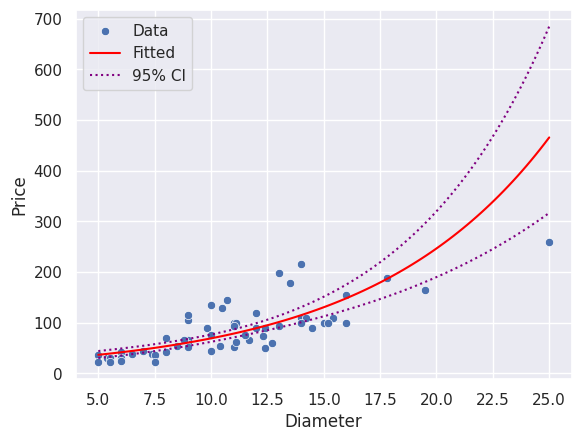

In [9]:

# 7. 95% Wald confidence intervals for regression coefficients
print(model_full.conf_int())



# 8. Plot price vs diameter with fitted values and 95% CI
new_diam = np.linspace(nambeware['Diam'].min(), nambeware['Diam'].max(), 100)
new_data = pd.DataFrame({'Diam': new_diam})
pred = model_full.get_prediction(new_data)
pred_summary = pred.summary_frame(alpha=0.05)

fig, ax = plt.subplots()
sns.scatterplot(x='Diam', y='Price', data=nambeware, ax=ax, label='Data')
ax.plot(new_diam, pred_summary['mean'], color='red', label='Fitted')
ax.plot(new_diam, pred_summary['mean_ci_lower'], color='purple', ls=':', label='95% CI')
ax.plot(new_diam, pred_summary['mean_ci_upper'], color='purple', ls=':')
ax.set_xlabel('Diameter')
ax.set_ylabel('Price')
ax.legend()
plt.show()

THE FOLLOWING IS JUST FOR FUN AND UNRELATED TO THE HW

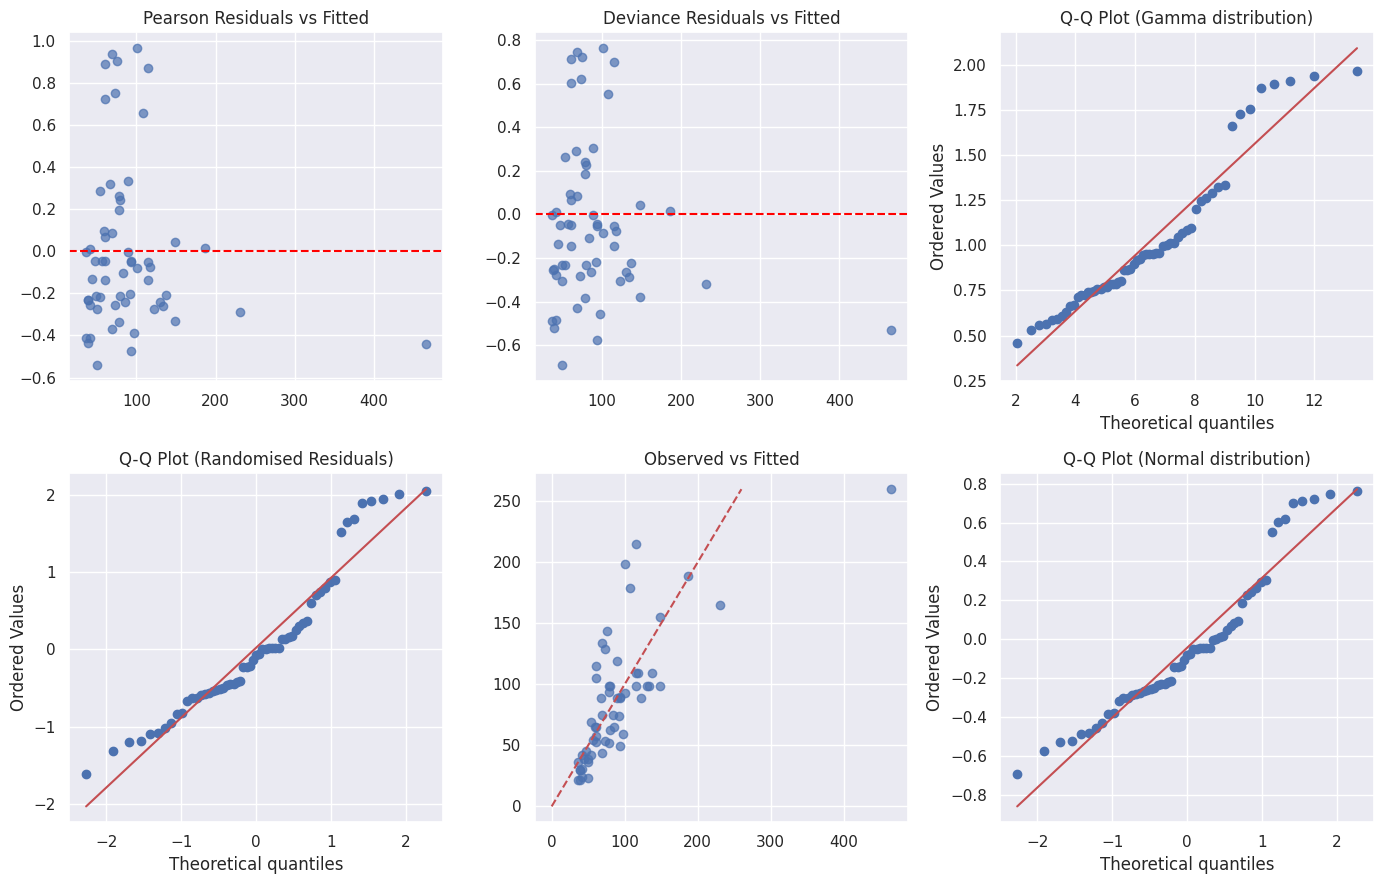